In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import  random_split
import os
import random

In [86]:
#   Network definition
class OneD_UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=10, kernel_size=1, stride=1)
        self.conv1_2 = nn.Conv1d(in_channels=10, out_channels=10, kernel_size=1, stride=1)
        self.downConv1 = nn.Conv1d(in_channels=10, out_channels=10,kernel_size=9, stride=2)

        self.conv2_1 = nn.Conv1d(in_channels=10, out_channels=13,kernel_size=1, stride=1)
        self.downConv2 = nn.Conv1d(in_channels=13, out_channels=13, kernel_size=9, stride=2)

        self.conv3_1 = nn.Conv1d(in_channels=13, out_channels=18, kernel_size=1, stride=1)
        self.downConv3 = nn.Conv1d(in_channels=18, out_channels=18, kernel_size=11, stride=2)

        self.conv4_1 = nn.Conv1d(in_channels=18, out_channels=24, kernel_size=1, stride=1)
        self.downConv4 = nn.Conv1d(in_channels=24, out_channels=24, kernel_size=9, stride=2)

        self.conv5_1 = nn.Conv1d(in_channels=24, out_channels=34, kernel_size=1, stride=1)
        self.upConv1 = nn.ConvTranspose1d(in_channels=34, out_channels=24, kernel_size=9, stride=2)

        self.conv6_1 = nn.Conv1d(in_channels=48, out_channels=24, kernel_size=1, stride=1)
        self.upConv2 = nn.ConvTranspose1d(in_channels=24, out_channels=18, kernel_size=11, stride=2)

        self.conv7_1 = nn.Conv1d(in_channels=36, out_channels=18, kernel_size=1, stride=1)
        self.upConv3 = nn.ConvTranspose1d(in_channels=18, out_channels=13, kernel_size=9, stride=2)

        self.conv8_1 = nn.Conv1d(in_channels=26, out_channels=13, kernel_size=1, stride=1)
        self.upConv4 = nn.ConvTranspose1d(in_channels=13, out_channels=10, kernel_size=9, stride=2)

        self.conv_9_1 = nn.Conv1d(in_channels=20, out_channels=10, kernel_size=1, stride=1)
        self.convOutput = nn.Conv1d(in_channels=10, out_channels=2, kernel_size=1, stride=1)

    def forward(self,x):
        x = self.conv1_1(x)
        x = torch.tanh(self.conv1_2(x))
        Intermediate1 = x   #  cropping to copy
        x = torch.tanh(self.downConv1(x))

        x = torch.tanh(self.conv2_1(x))
        Intermediate2 = x   #  cropping to copy
        x = torch.tanh(self.downConv2(x))

        x = torch.tanh(self.conv3_1(x))
        Intermediate3 = x   #  cropping to copy
        x = torch.tanh(self.downConv3(x))

        x = torch.tanh(self.conv4_1(x))
        Intermediate4 = x   #  cropping to copy
        x = torch.tanh(self.downConv4(x))

        x = torch.tanh(self.conv5_1(x))
        x = torch.tanh(self.upConv1(x))

        x = torch.tanh(self.conv6_1(torch.cat((Intermediate4,x),1)))
        x = torch.tanh(self.upConv2(x))

        x = torch.tanh(self.conv7_1(torch.cat((Intermediate3,x),1)))
        x = torch.tanh(self.upConv3(x))

        x = torch.tanh(self.conv8_1(torch.cat((Intermediate2,x),1)))
        x = torch.tanh(self.upConv4(x))

        x = torch.tanh(self.conv_9_1(torch.cat((Intermediate1,x),1)))
        x = torch.tanh(self.convOutput(x))
        voice = x[:,0,:]
        prob = torch.tanh(x[:,1,:])

        return voice,prob
        

In [83]:
#   paths
RAW_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav/'
NOISED_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_noised/'
DENOISED_DATA_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_denoised/'
LABEL_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/wav_labels/'
NOISE_SAMPLE_PATH = './cv-corpus-7.0-2021-07-21/zh-CN/office noise_WAV.wav'

files = os.listdir(NOISED_DATA_PATH)
sound_and_labels = []
for i in files:
    sound_and_labels.append((NOISED_DATA_PATH+i,DENOISED_DATA_PATH+i))

train_set, test_set = random_split(
    dataset=sound_and_labels,
    lengths=[2301,300],
    generator=torch.Generator().manual_seed(0)
)


In [87]:
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    file_count = 0
    currentLoss = 0
    net = OneD_UNet().to(device)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(net.parameters(),0.001)

    #   traverse audio files
    for soundFile in sound_and_labels:
        wave,_ = librosa.load(soundFile[0],sr=16000)        #   data
        label,_ = librosa.load(soundFile[1],sr=16000)       #   target
        prob = np.zeros(len(wave),dtype=np.float32)                       #   probability
        for i in range(len(label)):
            if label[i] != 0:
                prob[i] = 1

        #   sample 1000 windows lenth of 0.2s, grouped by batchsize(5)
        windowIndex = np.random.randint(low=0,high=len(wave)-3201,size=(200,5))
        for batch in windowIndex:
            data = torch.tensor([wave[batch[0]:batch[0]+3201],
                                wave[batch[1]:batch[1]+3201],
                                wave[batch[2]:batch[2]+3201],
                                wave[batch[3]:batch[3]+3201],
                                wave[batch[4]:batch[4]+3201]]).unsqueeze(1).to(device)

            target = torch.tensor([label[batch[0]:batch[0]+3201],
                                    label[batch[1]:batch[1]+3201],
                                    label[batch[2]:batch[2]+3201],
                                    label[batch[3]:batch[3]+3201],
                                    label[batch[4]:batch[4]+3201]]).to(device)

            probability = torch.tensor([prob[batch[0]:batch[0]+3201],
                                        prob[batch[1]:batch[1]+3201],
                                        prob[batch[2]:batch[2]+3201],
                                        prob[batch[3]:batch[3]+3201],
                                        prob[batch[4]:batch[4]+3201]]).to(device)

            #   training
            optimizer.zero_grad()
            loss = 0
            output_sound,output_prob = net(data)
            loss += criterion(output_sound,target)
            loss += criterion(output_prob,probability)
            currentLoss = loss
            loss.backward()
            optimizer.step()

        file_count+=1
        print("完成{}个文件".format(file_count))
        if file_count%200 == 0:
            #   验证并保存模型
            torch.save(net,"./models/fileCount is {},loss is {}.pth".format(file_count,currentLoss))


In [ ]:
train()

## test area

In [25]:
labels,_ = librosa.load(sound_and_labels[0][1], sr=16000)

prob = torch.zeros(len(labels))
for i in range(len(labels)):
    if labels[i] != 0:
        prob[i] = 1

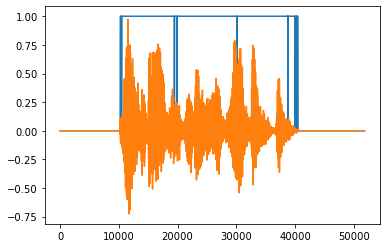

In [32]:
plt.plot(range(len(prob)),prob)
plt.plot(range(len(prob)),labels)
plt.show()

3201